In [7]:
import os

from dotenv import load_dotenv
load_dotenv()  # loads .env automatically

# THEN import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2 import robjects
from rpy2.robjects import FloatVector, globalenv

TOSTER = importr("TOSTER")


# JaCoCo Visualization

In [8]:
import os

import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

jacoco_path = '../../generated/code-analysis/jacoco.csv'

if not os.path.exists(jacoco_path):
    raise FileNotFoundError(f"Le fichier JaCoCo n'existe pas : {jacoco_path}. Exécutez le notebook 'notebooks/arrange data/JaCoCo.ipynb' pour le générer.")

out_jacoco_path = '../../generated/figures/jacoco'
if not os.path.exists(out_jacoco_path):
    os.makedirs(out_jacoco_path)

df_jacoco = pd.read_csv(jacoco_path)
cols = ['instruction', 'branch', 'line']
col_labels = ['instruction', 'branche', 'ligne']

## Boxplot

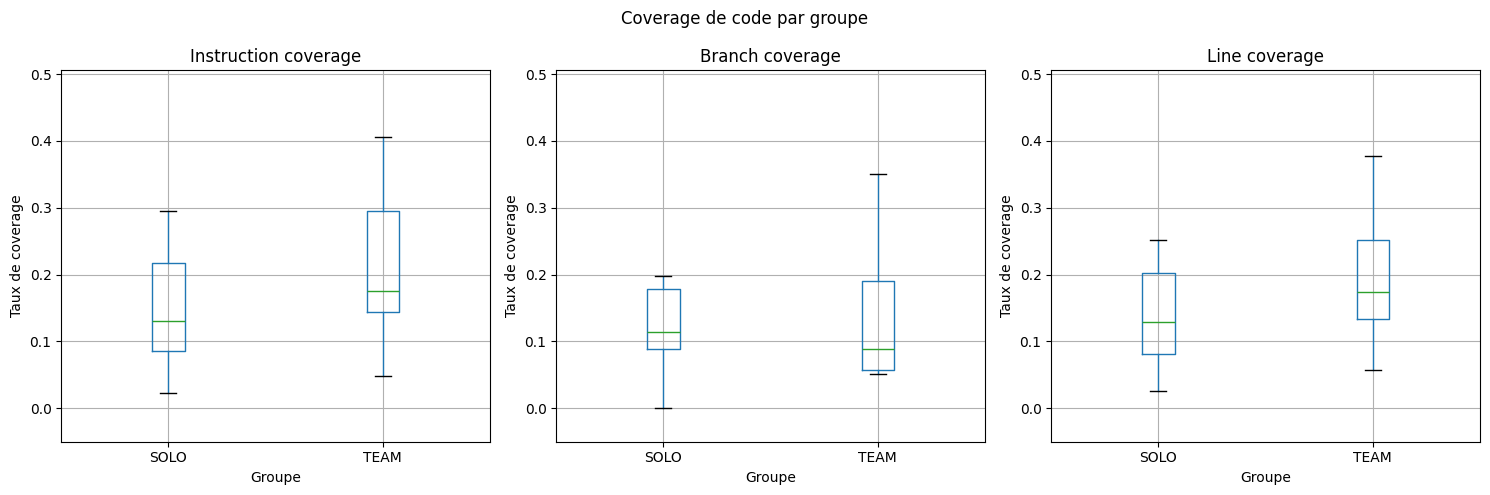

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

for i, metric in enumerate(cols):
    ax = axs[i]
    bp = df_jacoco.boxplot(column=metric, by='game_mode', ax=ax)
    ax.set_title(f'{metric.capitalize()} coverage')
    ax.set_ylabel('Taux de coverage')
    ax.set_xlabel('Groupe')
    ax.grid(True)
    ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par groupe')
plt.tight_layout()
plt.savefig(f"{out_jacoco_path}/coverage_by_group.pdf")
plt.show()


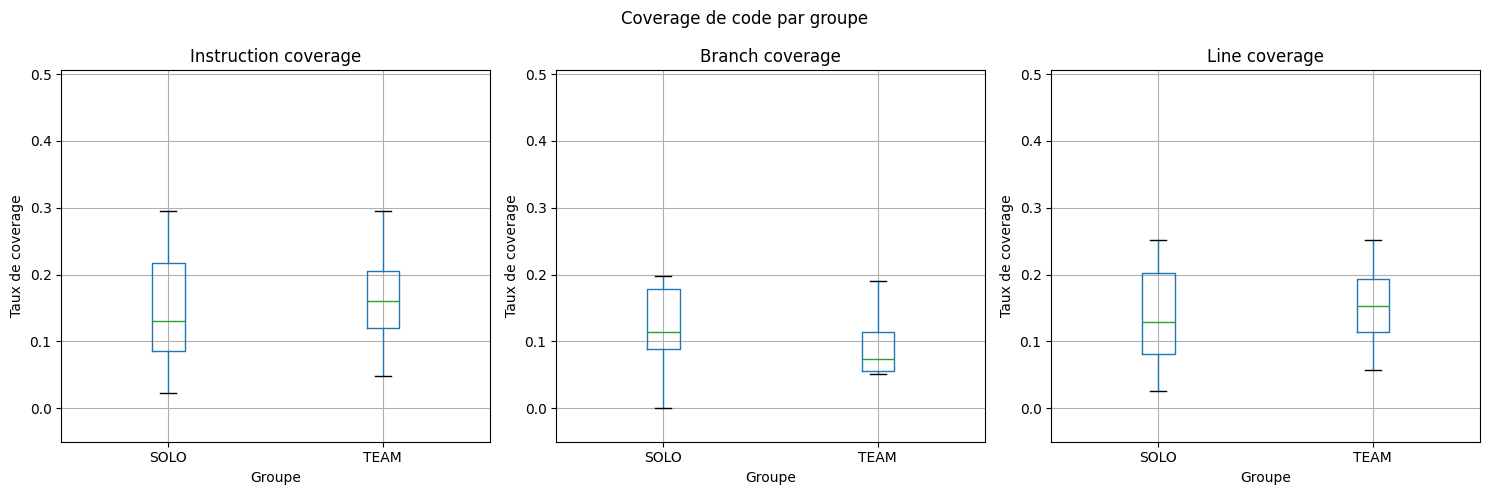

In [10]:
df_jacoco = pd.read_csv(jacoco_path)
cols = ['instruction', 'branch', 'line']
col_labels = ['instruction', 'branche', 'ligne']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

df_jacoco = df_jacoco[df_jacoco["instruction"] <= 0.4]

for i, metric in enumerate(cols):
    ax = axs[i]
    bp = df_jacoco.boxplot(column=metric, by='game_mode', ax=ax)
    ax.set_title(f'{metric.capitalize()} coverage')
    ax.set_ylabel('Taux de coverage')
    ax.set_xlabel('Groupe')
    ax.grid(True)
    ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par groupe')
plt.tight_layout()
plt.savefig(f"{out_jacoco_path}/coverage_by_group_wo_outlier.pdf")
plt.show()


In [ ]:
df_jacoco = pd.read_csv(jacoco_path)
cols = ['instruction', 'branch', 'line']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

df_jacoco = df_jacoco[df_jacoco["instruction"] <= 0.4]

for i, metric in enumerate(cols):
    ax = axs[i]
    bp = df_jacoco.boxplot(column=metric, by='game_mode', ax=ax)
    ax.set_title(f'{metric.capitalize()} coverage')
    ax.set_ylabel('Taux de coverage')
    ax.set_xlabel('Groupe')
    ax.grid(True)
    ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par groupe')
plt.tight_layout()
plt.savefig(f"{out_jacoco_path}/coverage_by_group_wo_outlier.pdf")
plt.show()
